# 3.3  Análisis de vocabulario para comparar períodos de 5 años

* Explorar frecuencias de palabras: Filtrado por frecuencia mínima. 

* Vocabulario: Medir qué proporción del vocabulario permanece activo (por encima del umbral de frecuencia) en los tres períodos.

* Identificar palabras emergentes: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.




## Consideraciones previas
### Preprocesamiento de texto para la generación de corpus
* En base a las 35179 iniciativas legislativas entre 2009 a 2024

#### Normalización
Antes de entrenar los modelos de word embeddings y con el objetivo de mejorar la calidad semántica del análisis, se aplicó un proceso de normalización  sobre los títulos de las iniciativas legislativas.Este procedimiento incluyó :

* Eliminar  caracteres como puntos, comas, comillas, espacios, brackets, etc.
* Convertir los números a su equivalente a palabras.
* Convertir a minúsculas.
* Lematizar.
* Remover stopwords.

**Limpieza de términos dominantes**

Dado el carácter jurídico y político del los títulos, se identificó presencia de términos de dominio legislativo, particularmente se tuvo en cuenta los asociados a proyectos de ley, que si bien frecuentes no aportan valor semántico específico al análisis temático sobre salud. Se implementó un filtro de n-gramas más frecuentes (n=2 a n=5).

Un n-grama es una secuencia de n elementos consecutivos de un texto o discurso. Los elementos pueden ser palabras, números, símbolos, fonemas, sílabas, letras, o pares de bases. 

* Se identificaron 552988 combinaciones de n-gramas de 2 a 5 con un número de frecuencia mínima de 1 vez. 

Los n-gramas más frecuentes (n=2 a n=5) a eliminar por dominio :

    * 'ley modificacion articulo', 
    * 'incorporacion articulo bis',
    * 'contrato trabajo ley',
    * 'ley modificacion',
    * 'modificacion articulo',
    * 'reproduccion expediente',
    * 'codigo penal',
    * 'articulo bis',
    * 'incorporacion articulo',
    * 'modificacion ley',
    * 'contrato trabajo', 
    * 'trabajo ley'

Estas frases o combinaciones de palabras fueron eliminados del los títulos buscando preservar aquellas palabras con contenido temático relevante para el análisis semántico en salud. Esta estrategia constribuye a reducir el ruido y a mejorar la estabilidad y expresividad de los embeddings entrenados por período, aunque también afecta la cantidad de tokens en el corpus y los modelos de lenguaje a aplicar.


**VOCABULARIO**
lista única de todas las palabras (o tokens) presentes en un conjunto de textos

**Palabras en base a normalización**
* 12865 palabras únicas en la muestra de 35179 iniciativas legislativas.
    * En promedio 27 veces de ocurrencia en la muestra, mediana 3 veces. Se identifican palabras con ocurrencia extremas.
        * Rango de frecuencia: [1- 10119]
        * Desviación estándar de frecuencia: 164 veces. Es decir, las mayor parte de las frecuencias de palabras de la muestra tienden a estar lejos de su media, se extienden sobre un rango de valores más amplio.
        * Top 4 palabras con mayores frecuencias:  nacional (10119), creacion (6033), regimen(5828), ley(5262). No se las eliminaron aún.

**Cantidad de palabras (token) por títulos**

* Cant_token (títulos no normalizado): promedio 21, std	11, min 2, mediana	19,  max 125 

* Cant_token_normalizado (titulos normalizados): promerdio	10, std	5, min	0, mediana 9, max 57

#### Iniciativa legislativa de ley sobre SALUD para período parlamentario entre 127 a 141
* 2848 iniciativas legislativas 

**Tokens**

* Cant_token: promedio	19, std	10, min	2, mediana	18, max 125
* Cant_token_normalizado: promedio	10,	std 5,	min 1, mediana 9, max 50

**De títulos normalizados**

N-gramas más frecuentes top 6 (mas diferencia con el resto). Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1: 
	
	* programa nacional  (2-grama)     208 veces
	* medico obligatorio (2-grama)     187 veces
	* programa medico obligatorio (3-grama)         153 veces
	* programa medico         153 veces
	* obligatorio pmo         150 veces
	* medico obligatorio pmo  150 veces

**VOCABULARIO**

Palabras más frecuentes

* 3221 palabrás únicas (del total de 12865). En promedio 9 veces (27 en el total) de ocurrencia en título, mediana 2 veces (3 en el total). Se identifica palabras con frecuencias extremas.
    * Rango: [1 - 836] ( [1- 10119] en el total)
    * Desviación estándar: 31 veces (164 veces en el total). Es decir, las mayor parte de las frecuencias de palabras de la muestra tienden a estar lejos de su media, se extienden sobre un rango de valores más amplio.
    * Top 5 palabras con mayores frecuencias:  nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
        *  nacional(10119),creacion(6033), regimen(5828),ley(5262) en el total



## 1. EDA

In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
import datetime
print(datetime.datetime.now().strftime("%Y%m%d%H%M"))

202507071735


In [3]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [4]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,35179,35179,HCDN246858,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,35179,33168,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,35179,29558,contrato de trabajo ley numero modificacion del articulo numero sobre licencias especiales,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,35179,28761,licencia especial,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,35179.0,NaN,NaN,NaN,21.123682,10.69187,2.0,14.0,19.0,27.0,125.0
Cant_token_normalizado,35179.0,NaN,NaN,NaN,9.76341,5.051387,0.0,6.0,9.0,12.0,57.0
Proyecto_girado_a_comisiones_SALUD,35179.0,NaN,NaN,NaN,0.12786,0.333939,0.0,0.0,0.0,0.0,1.0
Proyecto_SALUD,35179.0,NaN,NaN,NaN,0.085761,0.280015,0.0,0.0,0.0,0.0,1.0
Resultado,35179,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,34268,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Max_Orden,35179.0,NaN,NaN,NaN,2.253504,0.822105,1.0,2.0,2.0,3.0,8.0


In [5]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (3017, 14)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 14)


In [6]:
basetexto_df = basetexto_df[~(basetexto_df['Título normalizado']==" ")]
print("Conj. de datos de proyecto_SALUD sin título vacio:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD sin título vacio: (2848, 14)


In [7]:
basetexto_df[['Cant_token','Cant_token_normalizado']].describe()

,Cant_token,Cant_token_normalizado
count,2848.000000,2848.000000
mean,19.251053,9.766854
std,10.004802,4.657696
min,2.000000,1.000000
25%,12.000000,6.000000
50%,18.000000,9.000000
75%,24.000000,12.000000
max,125.000000,50.000000


Calculamos el promedio de tokens anuales y luego el promedio de esos promedios para obtener un resumen de 16 años  (media de las medias).

In [8]:
Temp = pd.pivot_table(basetexto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Año'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp

,Año,Cant_token,Cant_token_normalizado
0,2009,19.0,10.0
1,2010,18.0,9.0
2,2011,19.0,10.0
3,2012,17.0,8.0
4,2013,17.0,9.0
5,2014,18.0,9.0
6,2015,19.0,10.0
7,2016,16.0,8.0
8,2017,18.0,9.0
9,2018,18.0,9.0


 Para expresar el error asociado a este valor resumen, observamos las estadística descriptiva y calculamos el Error Estándar de la Media (SEM, Standard Error of the Mean) de los promedios anuales.

In [9]:
Temp.describe().T

,count,mean,std,min,25%,50%,75%,max
Año,16.0,2016.50000,4.760952,2009.0,2012.75,2016.5,2020.25,2024.0
Cant_token,16.0,17.59375,1.143369,15.5,17.00,18.0,18.25,19.0
Cant_token_normalizado,16.0,8.93750,0.680074,8.0,8.75,9.0,9.00,10.0


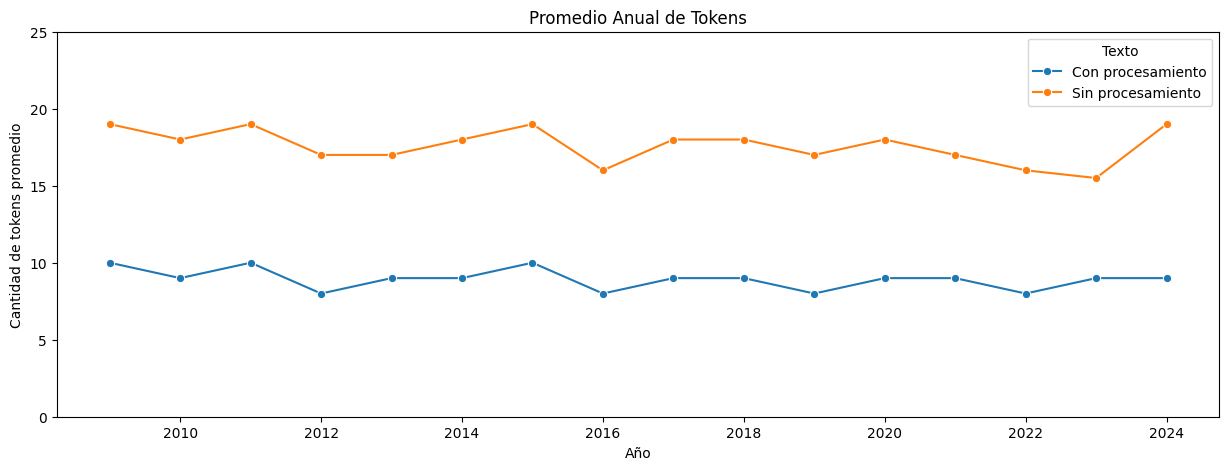

In [10]:
import matplotlib.ticker as ticker
sns.color_palette("pastel")
Temp1 = pd.melt(Temp, id_vars=['Año'], value_vars=['Cant_token_normalizado', 'Cant_token'])
Temp1.columns = ['Año','Texto','Cantidad de tokens promedio']
Temp1["Texto"] = Temp1["Texto"].map({'Cant_token': 'Sin procesamiento', 'Cant_token_normalizado': 'Con procesamiento'})

f, ax = plt.subplots(1, 1, figsize=(15, 5), sharey = True)
sns.lineplot(x='Año', y='Cantidad de tokens promedio', hue='Texto', data = Temp1, estimator='sum', errorbar= None , linestyle='-', ax = ax, marker="o")
legend_handles, _= ax.get_legend_handles_labels()

ax.set_title('Promedio Anual de Tokens')
plt.ylim(0, 25)
plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True, nbins=15))
#plt.savefig(BASE_DIR+"imagenes/evolucion_IL_a_tokennos.png")
plt.show()

In [11]:
from scipy import stats

# Calcula la media de los promedios anuales
promedios_anuales = Temp['Cant_token_normalizado']
n = len(promedios_anuales)
media_total = np.mean(promedios_anuales)

# Calcula la desviación estándar de los promedios anuales
desviacion_estandar = np.std(promedios_anuales, ddof=1) # ddof=1 para desviación estándar de la muestra

# Calcula el Error Estándar de la Media (SEM)
sem = desviacion_estandar / np.sqrt(n)
print('desviacion_estandar', desviacion_estandar)
print('sem',sem)

# Calcula el Intervalo de Confianza del 95%
alpha = 0.05  # Nivel de significancia
grados_libertad = n - 1
valor_critico_t = stats.t.ppf(1 - alpha / 2, grados_libertad)
intervalo_confianza = valor_critico_t * sem



desviacion_estandar 0.6800735254367721
sem 0.17001838135919303


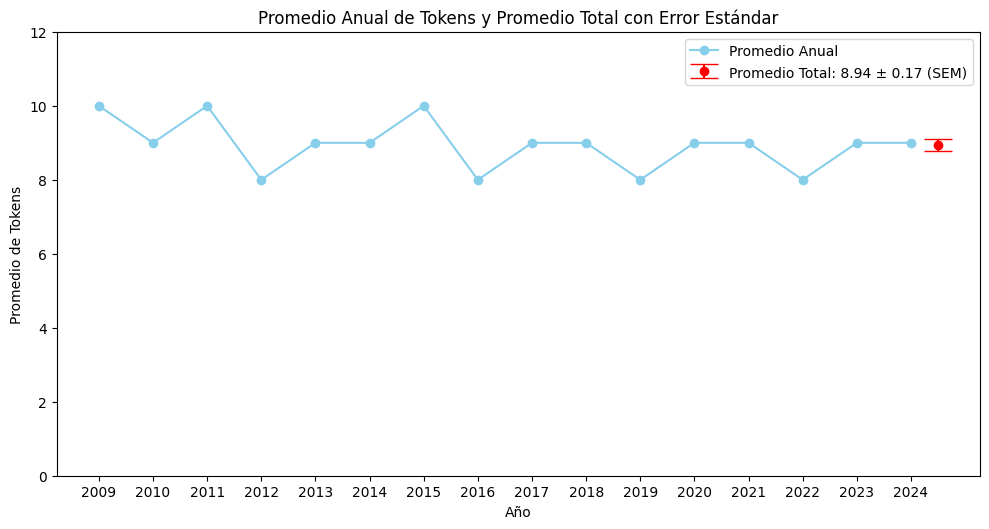

In [12]:
# --- Gráfico de Líneas con Punto Resumen y Error (SEM) ---
anos = Temp['Año']
plt.figure(figsize=(10,6))
plt.plot(anos, promedios_anuales, marker='o', linestyle='-', color='skyblue', label='Promedio Anual')
plt.errorbar(2024.5, media_total, yerr=sem, fmt='o', color='red', capsize=10, label=f'Promedio Total: {media_total:.2f} ± {sem:.2f} (SEM)')
plt.xlabel("Año")
plt.ylabel("Promedio de Tokens")
plt.title("Promedio Anual de Tokens y Promedio Total con Error Estándar")
plt.ylim(0, 12)
plt.xticks(anos.tolist() )
plt.legend()
plt.grid(False)
#plt.tight_layout()
plt.tight_layout(rect=[0, 0.05, 1, 0.95]) # Ajuste para evitar cortar etiquetas

plt.show()

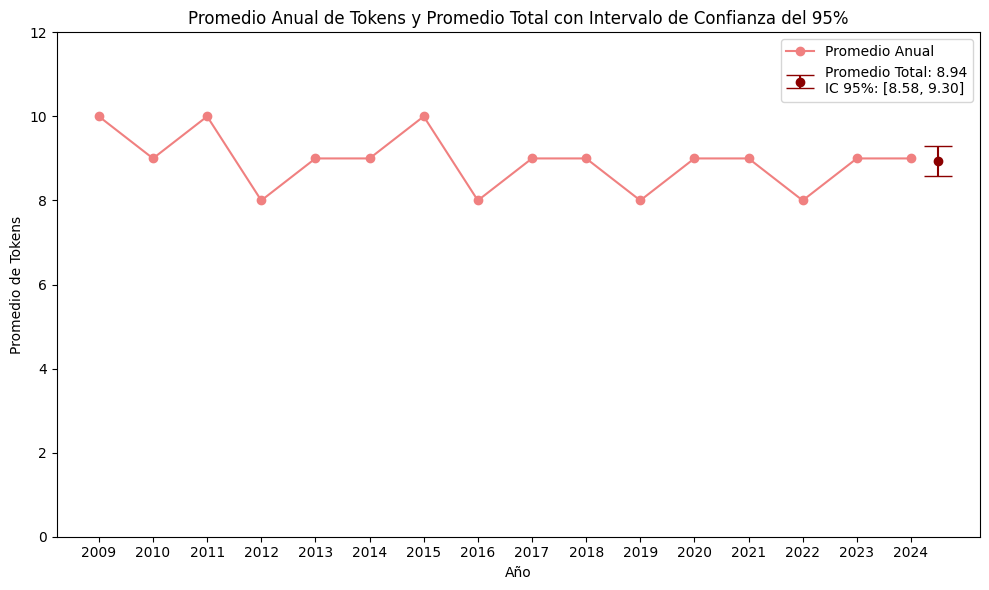

In [13]:
# --- Gráfico de Líneas con Punto Resumen y Error (Intervalo de Confianza del 95%) ---
plt.figure(figsize=(10, 6))
plt.plot(anos, promedios_anuales, marker='o', linestyle='-', color='lightcoral', label='Promedio Anual')
plt.errorbar(2024.5, media_total, yerr=intervalo_confianza, fmt='o', color='darkred', capsize=10,
             label=f'Promedio Total: {media_total:.2f}\nIC 95%: [{media_total - intervalo_confianza:.2f}, {media_total + intervalo_confianza:.2f}]')
plt.xlabel("Año")
plt.ylabel("Promedio de Tokens")
plt.title("Promedio Anual de Tokens y Promedio Total con Intervalo de Confianza del 95%")
plt.ylim(0, 12)
plt.xticks(anos.tolist())
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

**Normalizado**
* Media de los promedios anuales: 8.94
* Desviación estándar de los promedios anuales: 0.68
* SEM: 0.17

El SEM da una idea de la precisión con la que la media de los promedios anuales estima la "verdadera" media del promedio anual de tokens para el periodo de 16 años. El SEM es pequeño indica que la media de los promedios anuales es probablemente una estimación más precisa de esa "verdadera" media.

La media de 8.94 es una estimación del promedio anual de tokens para el periodo de 16 años. 
La mayoría de los promedios anuales de tokens se encuentran relativamente cerca de la media de 8.94. 

En general, los títulos normalizados de iniciativas legislativas de salud por año presentan 9 palabras promedio.

## 2. Corpus para los tres períodos

La selección de períodos de cada 5 años se basa a los periodos de presidencia. Es importante tener en cuenta a la hora de comparar el año 2020, dado que fue el año de inicio de pandemía covid 19, en donde se priorizaron proyectos de salud más que en los otros años. Ver notebook de EDA

* Periodo: 10 de diciembre de 2023 al presente
  Presidente Javier Milei
Ministro de Defensa
Dr. Luis Alfonso Petri

* Periodo: 10 de agosto de 2021 al 10 de diciembre de 2023
Presidente Alberto Fernández
Ministro de Defensa
Lic. Jorge Enrique Taiana

* Periodo: 10 de diciembre de 2019 al 10 de Agosto 2021
Presidente Alberto Fernández
Ministro de Defensa
Ing. Agustín Oscar Rossi

* Periodo: 10 de diciembre de 2015 al 10 de diciembre de 2019
Presidente Mauricio Macri
Ministro de Defensa
Ing. Julio César Martínez – 2015-2017
Dr. Oscar Raúl Aguad – 2017 al 2019

* Periodo: 10 de diciembre de 2011 al 10 de diciembre de 2015
Presidenta Cristina Fernández de Kirchner. Re-elección
Ministro de Defensa
Ing. Agustín Oscar Rossi – 2013 - 2015
Arturo Puricelli – 2011 - 2013

* Periodo: 10 de diciembre de 2007 al 10 de diciembre de 2011
Presidenta Cristina Fernández de Kirchner
Ministro de Defensa
Arturo Puricelli – 2010 - 2011
Nilda Garré – 2007 - 2010

In [14]:
basetexto_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Cant_token,2848.0,19.251053,10.004802,2.0,12.0,18.0,24.0,125.0
Cant_token_normalizado,2848.0,9.766854,4.657696,1.0,6.0,9.0,12.0,50.0
Proyecto_girado_a_comisiones_SALUD,2848.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Proyecto_SALUD,2848.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
Max_Orden,2848.0,2.445225,0.742946,1.0,2.0,2.0,3.0,7.0
Periodo,2848.0,134.391152,4.093235,127.0,131.0,135.0,138.0,141.0
Año,2848.0,2016.415028,4.105452,2009.0,2013.0,2017.0,2020.0,2024.0


In [15]:
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 

In [16]:
basetexto_df['Periodo_5anios'].value_counts() # frecuencia absoluto

Periodo_5anios
2019    1063
2014    1009
2009     776
Name: count, dtype: int64

In [17]:
Temp = pd.pivot_table(basetexto_df, values=['Cant_token','Cant_token_normalizado'], 
                      index=['Periodo_5anios'],
                       aggfunc={'Cant_token': 'median','Cant_token_normalizado': 'median'}).reset_index()
Temp.columns = ['Periodo_5anios',	'promedio Cant_token',	'promedio Cant_token_normalizado']
Temp

,Periodo_5anios,promedio Cant_token,promedio Cant_token_normalizado
0,2009,18.0,9.0
1,2014,18.0,9.0
2,2019,17.0,9.0


In [18]:
#concatenando titulos IL
PER5anios_df = basetexto_df.groupby('Periodo_5anios')['Título normalizado'].progress_apply('.'.join).reset_index() 
PER5anios_df['corpus']= PER5anios_df['Título normalizado'].progress_apply(lambda x: [sent.split() for sent in x.split('.')])
PER5anios_df['corpus'] = PER5anios_df['corpus'].progress_apply(lambda x: [token.remove(' ') if ' ' in token else token  for token in x ])


100%|██████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 3003.08it/s]


In [19]:
print(len(PER5anios_df['corpus'].values[0]))
PER5anios_df['corpus'].values[0]

776


[['declarar',
  'zona',
  'desastre',
  'emergencia',
  'economico',
  'social',
  'medioambiental',
  'plazo',
  'ciento',
  'ochenta',
  'corrido',
  'prorrogable',
  'departamento',
  'provincia',
  'san',
  'juan',
  'afectado',
  'temporal',
  'acaecido',
  'febrero'],
 ['paro',
  'cardiorrespiratorio',
  'espectaculo',
  'publico',
  'futbol',
  'regimen',
  'presupuesto',
  'minimo',
  'necesario',
  'materia',
  'prevencion',
  'atencion',
  'primaria',
  'basica'],
 ['creacion',
  'ambito',
  'ministerio',
  'salud',
  'nacion',
  'registro',
  'universal',
  'sanitario',
  'nacional'],
 ['incorporacion',
  'calendario',
  'nacional',
  'vacunacion',
  'dosis',
  'vacuna',
  'varicela',
  'caracter',
  'obligatorio'],
 ['atencion',
  'medica',
  'investigacion',
  'clinico',
  'epidemiologico',
  'capacitacion',
  'profesional',
  'deteccion',
  'diagnostico',
  'difusion',
  'tratamiento',
  'alergia',
  'alimentario',
  'declaracion',
  'inter',
  'nacional'],
 ['ley', 'taba

In [20]:
# GUARDAR OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
#with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'wb') as file: 
#    pickle.dump(PER5anios_df,file)

## 3. Analizando frecuencias de palabras por período 
Se tiene en cuenta los períodos parlamentaríos


In [21]:
freqs_list = []
for anios5 in PER5anios_df['Periodo_5anios'].to_list():

    print(anios5)
    subdf = PER5anios_df.loc[(PER5anios_df['Periodo_5anios']==anios5),]
    subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")                                 
    
    freqs = Counter()
    subdf['Título normalizado'].apply(lambda x: freqs.update(x.split())) # cualquier espacio.
    total_number = sum(freqs.values())
    print('Número total de tokens:', total_number)

    freqs_df = pd.DataFrame.from_dict(freqs, orient='index',
                                      columns=['Frecuencia'])
    freqs_df = freqs_df.reset_index()

    freqs_df = freqs_df.rename(columns={'index': 'Palabra'})
    mask = (freqs_df['Palabra'].str.len() > 1)
    print(freqs_df.shape)
    freqs_df = freqs_df.loc[mask]
    print(freqs_df.shape)
    print('Entradas removidas de 1 carácter.')
    print('Cantidad de tokens únicos:', freqs_df.shape[0])

    freqs_df = freqs_df.sort_values('Frecuencia').reset_index(drop=True)

    freqs_df['Porcentaje'] = freqs_df['Frecuencia'] / total_number

    
    freqs_df.to_csv(RESULTADOS_DIR+'./archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(anios5)+'.csv', index=False)

    freqs_df['Período'] = str(anios5)
    
    freqs_list.append(freqs_df)
    

2009
Número total de tokens: 7874
(1717, 2)
(1717, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1717
2014
Número total de tokens: 9735
(1969, 2)
(1969, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1969
2019
Número total de tokens: 10207
(1876, 2)
(1876, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1876


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3633415219.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3633415219.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3633415219.py:6: SettingWithCopyWarning: 
A value is trying to be set on a 

In [22]:
freqs_df = pd.concat(freqs_list) # Dataframe de frecuecias

In [23]:
freqs_df.head(2)

,Palabra,Frecuencia,Porcentaje,Período
0,xii,1,0.000127,2009
1,ipod,1,0.000127,2009


##### VOCABULARIO por período de 5 años

Analizando proyectos de IL de Salud:
* [2009 - 2014) - [127-131]
    * Número total de tokens: 7874
    * Número de tokens únicos: 1717
* [2014 - 2019) - [132-136]
    * Número total de tokens: 9735
    * Número de tokens únicos: 1969
* [2019 - 2024)- [137-141]
    * Número total de tokens: 10207
    * Número de tokens únicos: 1876

### Análisis general (Tres Periodos Combinados)

In [24]:
vocab_periodo = freqs_df['Período'].value_counts().reset_index() # vocabulario por períodos de 5 años
vocab_periodo

,Período,count
0,2014,1969
1,2019,1876
2,2009,1717


In [25]:
vocab_periodo.describe() # Estadística

,count
count,3.000000
mean,1854.000000
std,127.432335
min,1717.000000
25%,1796.500000
50%,1876.000000
75%,1922.500000
max,1969.000000


In [26]:
# Calculo la media de cantidad de palabras del vocabulario
 
n = len(vocab_periodo['count'])
media_total = np.mean(vocab_periodo['count'])

# Calcula la desviación estándar de los promedios anuales
desviacion_estandar = np.std(vocab_periodo['count'], ddof=1) # ddof=1 para desviación estándar de la muestra

# Calcula el Error Estándar de la Media (SEM)
sem = desviacion_estandar / np.sqrt(n)
print('media de vocabulario por periodo (cantidad de palabras únicas)',media_total)
print('desviacion_estandar', desviacion_estandar)
coeficiente_variacion = (desviacion_estandar / media_total) * 100
print('coeficiente_variacion ',coeficiente_variacion)
print('sem',sem)

# Calcula el Intervalo de Confianza del 95%
alpha = 0.05  # Nivel de significancia
grados_libertad = n - 1
valor_critico_t = stats.t.ppf(1 - alpha / 2, grados_libertad)
intervalo_confianza = valor_critico_t * sem
print("intervalo de confianza: ",intervalo_confianza)

media de vocabulario por periodo (cantidad de palabras únicas) 1854.0
desviacion_estandar 127.43233498606232
coeficiente_variacion  6.873372976594514
sem 73.57309290766565
intervalo de confianza:  316.5594690313555


La desviación estándar es de 127 palabras, el Coeficiente de Variación de 7 (dispersión relativa), lo que indica que los vocabularios o las cantidades de palabras únicas por período están más dispersas, la media 1854 no es tan representativa para los tres periodos a procesar.

In [27]:
freqs_df = freqs_df.sort_values(by = 'Frecuencia', ascending =False)

In [28]:

freqs_df.to_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_all.csv', index=False)


In [30]:
# Suponiendo que tu DataFrame se llama 'df'
print("--- Análisis del Vocabulario para los Tres Periodos Combinados ---")

# 1. Tamaño total del vocabulario único
vocabulario_total = freqs_df['Palabra'].nunique()
print(f"Tamaño total del vocabulario único en los tres periodos: {vocabulario_total}")

# 2. Frecuencia total de todas las palabras
frecuencia_total = freqs_df['Frecuencia'].sum()
print(f"Frecuencia total de todas las palabras en los tres periodos: {frecuencia_total}")


--- Análisis del Vocabulario para los Tres Periodos Combinados ---
Tamaño total del vocabulario único en los tres periodos: 3221
Frecuencia total de todas las palabras en los tres periodos: 27816


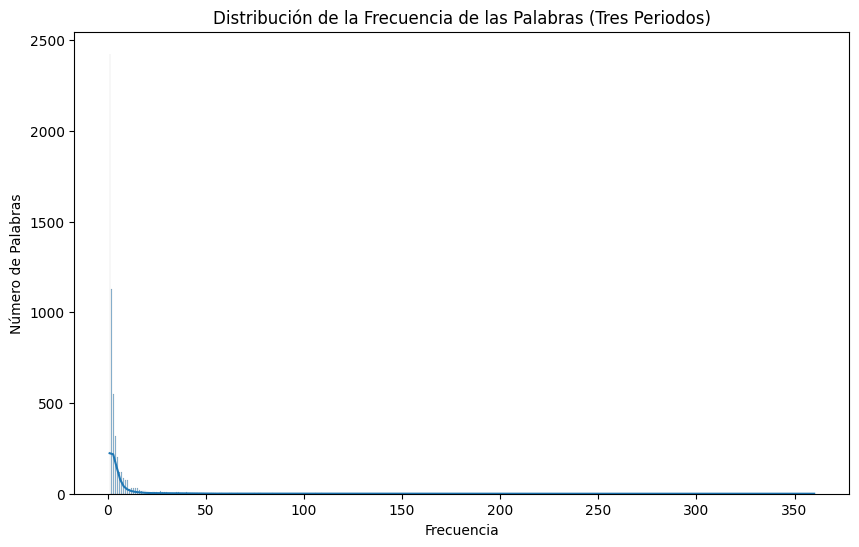

In [31]:
# 3. Distribución de la frecuencia de las palabras
plt.figure(figsize=(10, 6))
sns.histplot(freqs_df['Frecuencia'], bins='auto', kde=True)
plt.title('Distribución de la Frecuencia de las Palabras (Tres Periodos)')
plt.xlabel('Frecuencia')
plt.ylabel('Número de Palabras')
plt.show()

<Axes: xlabel='Frecuencia'>

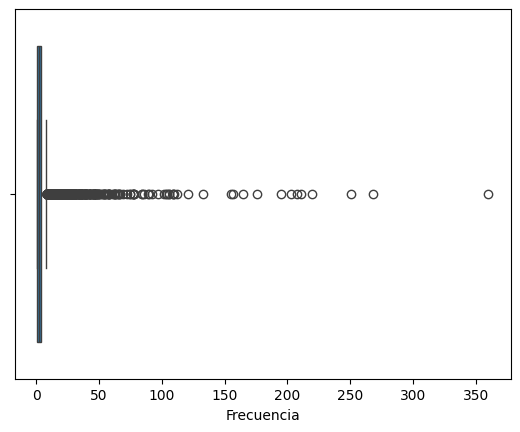

In [32]:
sns.boxplot(x = 'Frecuencia', data=freqs_df)

In [33]:
freqs_df.describe(include = 'all') 

,Palabra,Frecuencia,Porcentaje,Período
count,5562,5562.000000,5562.000000,5562
unique,3221,NaN,NaN,3
top,nacional,NaN,NaN,2014
freq,3,NaN,NaN,1969
mean,NaN,5.001079,0.000539,NaN
std,NaN,13.881949,0.001476,NaN
min,NaN,1.000000,0.000098,NaN
25%,NaN,1.000000,0.000103,NaN
50%,NaN,2.000000,0.000196,NaN
75%,NaN,4.000000,0.000392,NaN


In [34]:
rango = np.max(freqs_df['Frecuencia']) - np.min(freqs_df['Frecuencia'])
coeficiente_variacion = (desviacion_estandar / freqs_df['Frecuencia'].mean()) * 100
print('Rango ',rango)
print('Coeficiente_variacion ',coeficiente_variacion)


Rango  359
Coeficiente_variacion  2548.0969484917982


* El promedio de frecuencia de una palabra en período de 5 años es: 5
* La mediana de frecuencua  de una palabra en período de 5 años es: 2
* La desviación estandar de una palabra en período de 5 años es: 14
* El rango de frecuencia de una palabra en período de 5 años es: 359

Existe un alta variabilidad de frecuencia de palabra en período de 5 años (rango = 359 frecuencia). La mayorías de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se concentran alrededor de frecuencia=2. El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4. 

In [35]:
def eliminar_outliers_iqr(df, columna):
    """
    Separa los outliers y devuelve dos DataFrames:
    - df_limpio: sin outliers
    - df_outliers: con los valores atípicos detectados

    Parámetros:
    df (pd.DataFrame): DataFrame de pandas
    columna (str): Nombre de la columna a analizar

    Retorna:
    df_limpio (pd.DataFrame): DataFrame sin outliers
    df_outliers (pd.DataFrame): DataFrame solo con outliers
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print("Q1:",Q1)
    print("Q3:",Q3)
    print('limite_inferior:', limite_inferior)
    print('limite_superior:', limite_superior)


    # Filtrar datos
    df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    df_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return df_limpio, df_outliers    


In [36]:
# Detectar outliers
freqs_limpio_df , outliers_df = eliminar_outliers_iqr(freqs_df, 'Frecuencia')
display("Outliers detectados:\n", outliers_df)

Q1: 1.0
Q3: 4.0
limite_inferior: -3.5
limite_superior: 8.5


'Outliers detectados:\n'

,Palabra,Frecuencia,Porcentaje,Período
1875,nacional,360,0.035270,2019
1968,nacional,268,0.027530,2014
1874,creacion,251,0.024591,2019
1967,creacion,220,0.022599,2014
1873,programa,211,0.020672,2019
...,...,...,...,...
1551,hospital,9,0.001143,2009
1552,estudio,9,0.001143,2009
1553,forma,9,0.001143,2009
1554,tabaquismo,9,0.001143,2009


Se considera que una palabra en periodo de 5 años con frecuencia superior 8 es una palabra de frecuencia extrema o especial.

In [37]:
print("Cantidad de palabras únicas por período que superan las 8 veces en alguno de los tres períodos  - OUTLIERS:", len(outliers_df.Palabra.unique()))

Cantidad de palabras únicas por período que superan las 8 veces en alguno de los tres períodos  - OUTLIERS: 316


* Existe un alta variabilidad de frecuencia de palabra en período de 5 años (rango = 350 frecuencia).
* La mayoría de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se  concentran alrededor de frecuencia=2. 
* El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4.
* Se considera que una palabra en período de 5 años con frecuencia superior 8 es una palabra de frecuencia extrema o especial. 
* Hay 316 palabras únicas por período que superan las 8 veces en alguno de los tres períodos. 
* Total de palabras con frecuencia extrema en alguno de los tres periodo = 622 


### Análisis por Periodo:  Por período de 5 años

In [38]:
from scipy.stats import bootstrap


# Para una primera aproximación y visualización de la incertidumbre, el bootstrap de percentiles (o la salida por defecto de scipy.stats.bootstrap) es un buen comienzo.
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95, random_state=42) # Añadimos random_state para reproducibilidad
    return (res.confidence_interval.low, res.confidence_interval.high)

def confidence_intervals_bca(data):
    """
    Calcula el intervalo de confianza del 95% para la media utilizando el método BCa bootstrap.
    """
    res = bootstrap((data,), np.mean, confidence_level=0.95, method='BCa', random_state=42)
    return (res.confidence_interval.low, res.confidence_interval.high)




Bootstrap de Percentiles (Percentile Bootstrap):

Cómo funciona: El intervalo de confianza se construye tomando los percentiles apropiados (por ejemplo, el 2.5% y el 97.5% para un intervalo del 95%) de la distribución de las estadísticas bootstrap.
Ventajas: Conceptualmente simple y fácil de entender.
Desventajas: Su precisión puede ser limitada, especialmente con muestras pequeñas o distribuciones sesgadas. No siempre es transformacionalmente invariante (el intervalo de confianza para una función del parámetro no siempre es la función de los límites del intervalo de confianza).


--- Análisis por Periodo ---

--- Periodo: 2009 ---
Tamaño del vocabulario único: 1717
Frecuencia total de palabras: 7874
Frecuencia media de las palabras (BCa): 4.59 (IC 95%: 4.12, 5.23)
['nacional' 'creacion' 'salud' 'programa' 'social' 'regimen' 'ley'
 'obligatorio' 'medico' 'declarar']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1716,nacional,208,0.026416,2009
1715,creacion,157,0.019939,2009
1714,salud,133,0.016891,2009
1713,programa,112,0.014224,2009
1712,social,110,0.013970,2009
1711,regimen,106,0.013462,2009
1710,ley,102,0.012954,2009
1709,obligatorio,84,0.010668,2009
1708,medico,78,0.009906,2009
1707,declarar,78,0.009906,2009


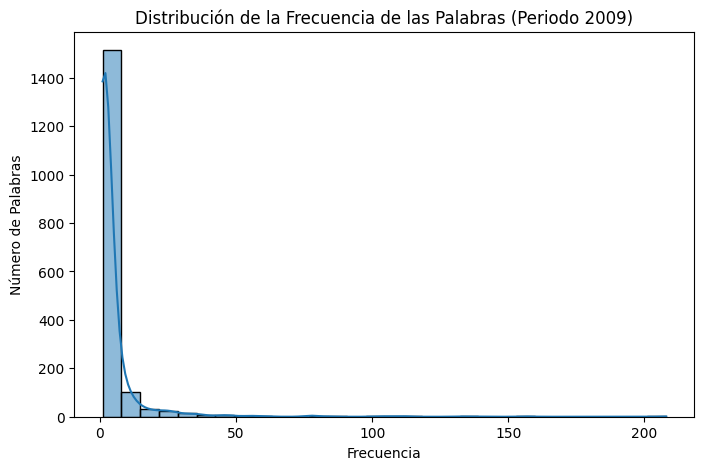


--- Periodo: 2014 ---
Tamaño del vocabulario único: 1969
Frecuencia total de palabras: 9735
Frecuencia media de las palabras (BCa): 4.94 (IC 95%: 4.44, 5.66)
['nacional' 'creacion' 'regimen' 'programa' 'salud' 'medico' 'obligatorio'
 'social' 'persona' 'tratamiento']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1968,nacional,268,0.027530,2014
1967,creacion,220,0.022599,2014
1966,regimen,203,0.020853,2014
1965,programa,165,0.016949,2014
1964,salud,155,0.015922,2014
1963,medico,121,0.012429,2014
1962,obligatorio,97,0.009964,2014
1961,social,92,0.009450,2014
1960,persona,90,0.009245,2014
1959,tratamiento,89,0.009142,2014


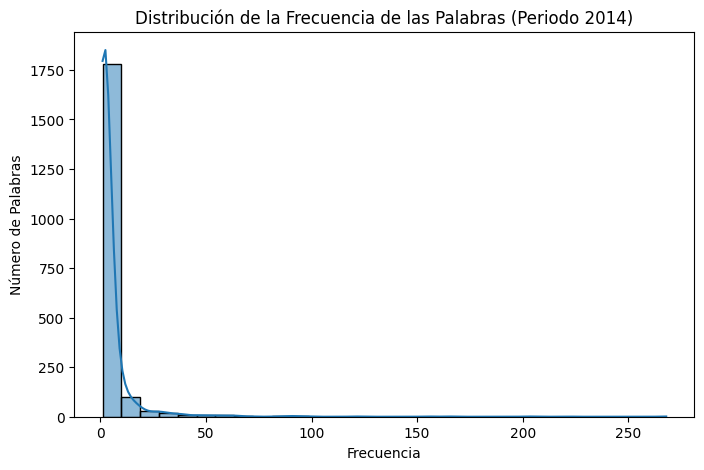


--- Periodo: 2019 ---
Tamaño del vocabulario único: 1876
Frecuencia total de palabras: 10207
Frecuencia media de las palabras (BCa): 5.44 (IC 95%: 4.84, 6.35)
['nacional' 'creacion' 'programa' 'salud' 'regimen' 'medico' 'persona'
 'obligatorio' 'covid' 'integral']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1875,nacional,360,0.035270,2019
1874,creacion,251,0.024591,2019
1873,programa,211,0.020672,2019
1872,salud,195,0.019105,2019
1871,regimen,176,0.017243,2019
1869,medico,109,0.010679,2019
1870,persona,109,0.010679,2019
1868,obligatorio,106,0.010385,2019
1867,covid,104,0.010189,2019
1866,integral,103,0.010091,2019


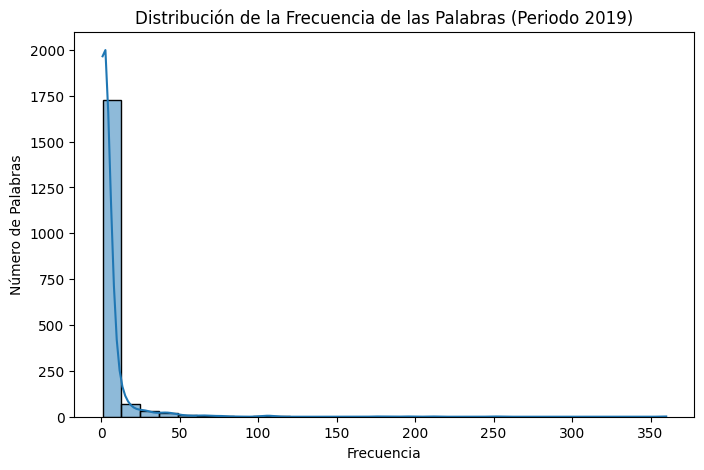

In [39]:
print("\n--- Análisis por Periodo ---")
for periodo in ['2009','2014','2019']:

    df_periodo = freqs_df[freqs_df['Período'] == periodo]
    print(f"\n--- Periodo: {periodo} ---")

    # 1. Tamaño del vocabulario único por periodo
    vocabulario_periodo = df_periodo['Palabra'].nunique()
    print(f"Tamaño del vocabulario único: {vocabulario_periodo}")

    # 2. Frecuencia total de palabras por periodo
    frecuencia_total_periodo = df_periodo['Frecuencia'].sum()
    print(f"Frecuencia total de palabras: {frecuencia_total_periodo}")

    # 3. Frecuencia media de las palabras por periodo con intervalos de confianza bootstrap
    frecuencias_periodo = df_periodo['Frecuencia'].values
    if len(frecuencias_periodo) > 0:
  
        media_frecuencia = np.mean(frecuencias_periodo)
        intervalo_confianza = confidence_intervals_bca(frecuencias_periodo)
        # Esto nos da una idea del rango plausible para la verdadera frecuencia media de las palabras en ese periodo.
        print(f"Frecuencia media de las palabras (BCa): {media_frecuencia:.2f} (IC 95%: {intervalo_confianza[0]:.2f}, {intervalo_confianza[1]:.2f})")

        temp = df_periodo.sort_values('Frecuencia', ascending=False)
        print(temp.head(10).Palabra.unique())
        display("Top 10 palabras",temp.head(10))

        
        # Visualización de la distribución de frecuencias por periodo
        plt.figure(figsize=(8, 5))
        sns.histplot(df_periodo['Frecuencia'], bins=30, kde=True)
        plt.title(f'Distribución de la Frecuencia de las Palabras (Periodo {periodo})')
        plt.xlabel('Frecuencia')
        plt.ylabel('Número de Palabras')
        plt.show()
    else:
        print("No hay palabras en este periodo.")




* Frecuencia media con intervalos de confianza: el promedio de ocurrencias de una palabra en el periodo, es en general, un frecuencia de ocurrencia igual a 5. 
* El intervalo de confianza te proporciona un rango dentro del cual es probable que se encuentre la verdadera frecuencia media de las palabras en la población 
(todos los posibles títulos de ese periodo). Los intervalos de confianza para el promedio de ocurrencias de una palabra en el periodo para diferentes periodos en general no se superponen, se observa para el periodo 2019 una frecuencia media de 6.


In [40]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]
pares_periodos = pares_primer_paso(['2009','2014','2019'])
pares_periodos

[('2009', '2014'), ('2014', '2019')]


--- Palabras en Común entre Pares de Periodos ---

Palabras en común entre 2009 y 2014: 1083
% 29.381


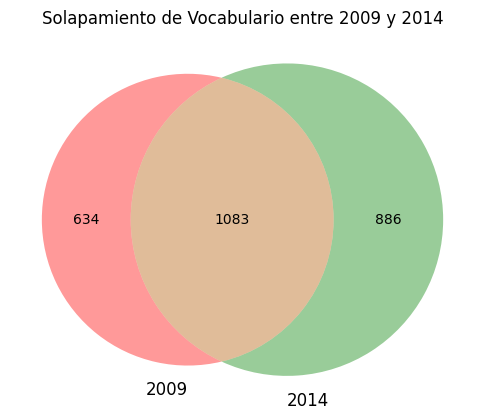

['excesivo', 'grave', 'maternal', 'instituto', 'medicamentosa', 'electronico', 'terciario', 'agosto', 'ocurrido']

Palabras en común entre 2014 y 2019: 1130
% 29.389


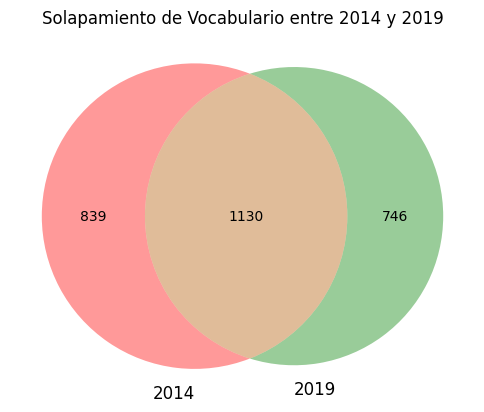

['grave', 'instituto', 'electronico', 'agosto', 'descanso', 'monoxido', 'ocurrido', 'jubilacion', 'protesis']


In [41]:
print("\n--- Palabras en Común entre Pares de Periodos ---")
for par in pares_periodos:
    periodo1 = par[0]
    periodo2 = par[1]
    vocabulario1 = set(freqs_df[freqs_df['Período'] == periodo1]['Palabra'])
    vocabulario2 = set(freqs_df[freqs_df['Período'] == periodo2]['Palabra'])
    palabras_en_comun = vocabulario1.intersection(vocabulario2)
    total = len(vocabulario1) + len(vocabulario2)
    
    num_comunes = len(palabras_en_comun)
    print(f"\nPalabras en común entre {periodo1} y {periodo2}: {num_comunes}")
    print("%",round((num_comunes/total)*100,3))

    # Visualización del solapamiento (opcional, para una idea general)
    from matplotlib_venn import venn2
    plt.figure(figsize=(6, 6))
    venn2([vocabulario1, vocabulario2], set_labels=(str(periodo1), str(periodo2)))
    plt.title(f'Solapamiento de Vocabulario entre {periodo1} y {periodo2}')
    plt.show()

    print(list(palabras_en_comun)[1:10])

Palabras en común: El número de palabras en común y los diagramas de Venn muestran la superposición del vocabulario entre los diferentes periodos. 
En general, 29% del vocabulario total de pares de periodos a comparar es compartido, es decir  que solo el 29% de las palabras únicas que aparecen en la unión de los vocabularios de ambos periodos están presentes en ambos periodos. El 71% restante del vocabulario total aparece solo en uno de los dos periodos comparados.


Influencia en Vocabularios Pequeños:

En vocabularios pequeños, un solapamiento del 29% puede tener un impacto significativo en el análisis de cambio semántico:

* Menos palabras para comparar: Cuanto menor sea el solapamiento, menor será el conjunto de palabras para las cuales puedes directamente intentar detectar un cambio semántico comparando su uso o representaciones a través del tiempo.

* Mayor impacto de palabras nuevas y desaparecidas: Un porcentaje considerable del vocabulario siendo nuevo en un periodo o desapareciendo del otro puede indicar cambios temáticos o en el foco del discurso, lo cual podría estar relacionado con cambios semánticos en las palabras compartidas. Sin embargo, también dificulta el análisis directo del cambio semántico para las palabras no compartidas.

* Potencial para inestabilidad en modelos: Si intentas entrenar modelos de embedding o de lenguaje en vocabularios pequeños con bajo solapamiento, la falta de datos compartidos puede llevar a representaciones inestables o poco confiables para las palabras.
En resumen, un solapamiento del 29% en un vocabulario pequeño sugiere que hay una discontinuidad considerable en el léxico utilizado entre los periodos comparados, lo que puede dificultar la detección robusta de cambios semánticos utilizando métodos que se basan en la comparación directa de representaciones de palabras compartidas.

#### Palabras emergentes

* Objetivo: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.

Técnicas comunes:

* Comparación de frecuencias relativas entre períodos : z-score, log-odds ratio con prior.

* TF-IDF por período: resalta palabras distintivas en un segmento temporal.

In [42]:
Vocab_periodo_df =  pd.pivot_table(freqs_df, values=['Frecuencia'], columns=['Período'],
                      index=['Palabra']).reset_index()

Vocab_periodo_df.columns = [col[1] if col[1] else col[0] for col in Vocab_periodo_df.columns]
Vocab_periodo_df.fillna(0, inplace=True) # Rellenar valores faltantes con 0
Vocab_periodo_df

,Palabra,2009,2014,2019
0,1a1,0.0,2.0,0.0
1,1a2,0.0,2.0,0.0
2,abastecimiento,0.0,0.0,2.0
3,abdominal,0.0,1.0,0.0
4,abierto,0.0,2.0,4.0
...,...,...,...,...
3216,zonal,1.0,0.0,0.0
3217,zoonosis,0.0,3.0,1.0
3218,zoonotica,1.0,1.0,0.0
3219,zooterapia,1.0,0.0,0.0


**Calcular diferencias y Z-Score para identificar emergentes**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

def calcular_diferencia_zscore(df, periodo1, periodo2, min_frecuencia=5):
    """
    Calcula la diferencia de frecuencia normalizada (Z-Score de la diferencia)
    para identificar palabras emergentes entre dos periodos.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'porcentaje', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación.
        min_frecuencia (int): Frecuencia mínima en al menos uno de los periodos para considerar la palabra.

    Returns:
        pd.DataFrame: DataFrame con palabras compartidas, sus frecuencias en ambos periodos,
                      diferencia de frecuencia y Z-Score de la diferencia.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo2}')

    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)

    # Filtrar palabras con baja frecuencia en ambos periodos
    df_comparacion = df_comparacion[
        (df_comparacion[f'Frecuencia_{periodo1}'] >= min_frecuencia) |
        (df_comparacion[f'Frecuencia_{periodo2}'] >= min_frecuencia)
    ]

    df_comparacion['Diferencia_frecuencia'] = df_comparacion[f'Frecuencia_{periodo2}'] - df_comparacion[f'Frecuencia_{periodo1}']
    df_comparacion['zscore_diferencia'] = zscore(df_comparacion['Diferencia_frecuencia'])

    return df_comparacion.sort_values(by='zscore_diferencia', ascending=False)

def visualizar_palabras_emergentes(df_resultados, top_n=20, title="Palabras Emergentes (Z-Score Diferencia)"):
    """
    Visualiza las N palabras con el Z-Score de diferencia más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'zscore_diferencia'.
        top_n (int): Número de palabras a mostrar.
        title (str): Título del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='zscore_diferencia', ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Z-Score de la Diferencia de Frecuencia")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()



--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes, Z > 1.5 : 18


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2014,Porcentaje_2014,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
regimen,106.0,0.013462,203.0,0.020853,97.0,8.718495
creacion,157.0,0.019939,220.0,0.022599,63.0,5.577928
nacional,208.0,0.026416,268.0,0.027530,60.0,5.300819
programa,112.0,0.014224,165.0,0.016949,53.0,4.654231
persona,46.0,0.005842,90.0,0.009245,44.0,3.822905
medico,78.0,0.009906,121.0,0.012429,43.0,3.730535
alimento,29.0,0.003683,63.0,0.006471,34.0,2.899208
sistema,26.0,0.003302,58.0,0.005958,32.0,2.714469
tratamiento,58.0,0.007366,89.0,0.009142,31.0,2.622099


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3568983009.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


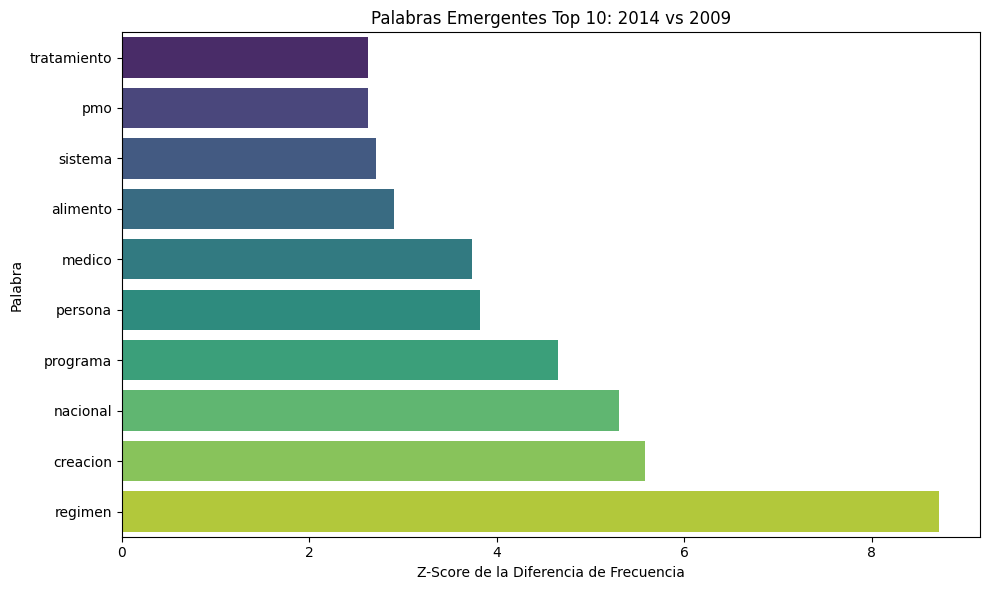


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 24


,Frecuencia_2014,Porcentaje_2014,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
covid,0.0,0.000000,104.0,0.010189,104.0,9.441082
nacional,268.0,0.027530,360.0,0.035270,92.0,8.338943
integral,48.0,0.004931,103.0,0.010091,55.0,4.940681
crear,0.0,0.000000,53.0,0.005193,53.0,4.756992
pandemia,0.0,0.000000,47.0,0.004605,47.0,4.205922
programa,165.0,0.016949,211.0,0.020672,46.0,4.114077
salud,155.0,0.015922,195.0,0.019105,40.0,3.563008
sanitario,27.0,0.002773,63.0,0.006172,36.0,3.195628
creacion,220.0,0.022599,251.0,0.024591,31.0,2.736403


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3568983009.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


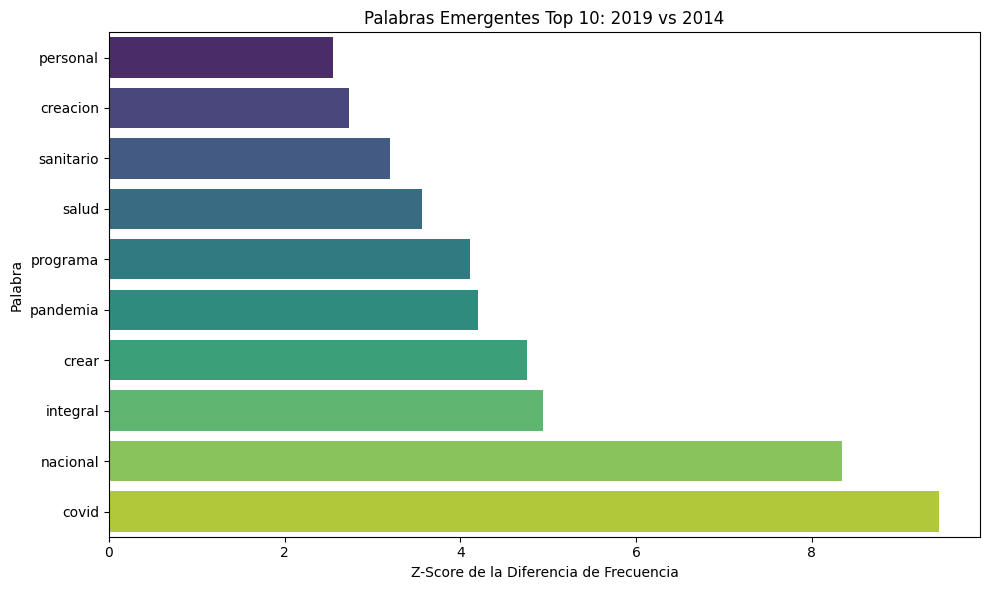


--- Comparación entre 2009 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 24


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
nacional,208.0,0.026416,360.0,0.035270,152.0,9.583860
covid,0.0,0.000000,104.0,0.010189,104.0,6.481570
programa,112.0,0.014224,211.0,0.020672,99.0,6.158415
creacion,157.0,0.019939,251.0,0.024591,94.0,5.835259
integral,26.0,0.003302,103.0,0.010091,77.0,4.736532
regimen,106.0,0.013462,176.0,0.017243,70.0,4.284115
persona,46.0,0.005842,109.0,0.010679,63.0,3.831697
salud,133.0,0.016891,195.0,0.019105,62.0,3.767066
crear,0.0,0.000000,53.0,0.005193,53.0,3.185387


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3568983009.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


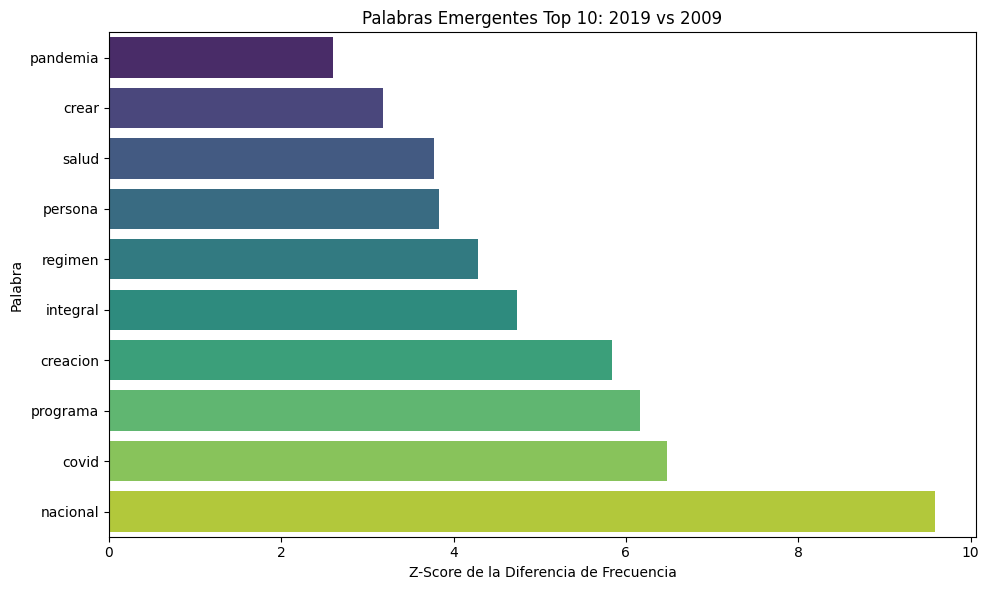

In [44]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]

for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    resultados = calcular_diferencia_zscore(freqs_df.copy(), p1, p2, min_frecuencia=5)
    resultados.to_csv(RESULTADOS_DIR+'/archivos_out/zscore_'+p1+'_'+p2+'.csv')
    emergentes = resultados[resultados['zscore_diferencia']>1.5]
    print("Cantidad de palabras emergentes, Z > 1.5 :",len(emergentes))
    display(emergentes.head(10))  # Mostrar las 10 palabras más emergentes
    visualizar_palabras_emergentes(emergentes,10, title=f"Palabras Emergentes Top 10: {p2} vs {p1}")


El Z-Score estandariza la diferencia, permitiendo comparar la magnitud del cambio relativa a la variabilidad de todas las diferencias. Un Z-Score positivo alto sugiere una mayor emergencia en el segundo periodo. Se consideraron emergentes aquellas palabras con un z-score superior a 1.5, es decir, cuyo crecimiento superó en al menos 1.5 desviaciones estándar el crecimiento promedio del conjunto. Este umbral permite detectar términos que se destacan significativamente sin restringir el análisis a casos extremos.

* Se observan palabras de alta frecuencia con Z-Scores extremos, tal que están presentes en los tres períodos. Por ejemplo "nacional" y "programa", "creacion" son palabras con alta frecuencia y Z-scores extremos entre los períodos comparados 2009 y 2019. Podriamos interpretar que sus usos se ha incrementado en el período (2019-2024] aún más en relación con el resto del vocabulario del periodo (2009-2014]. Al estar presentes en los tres periodos, las palabras pueden indicar continuidad de temática centrales sobre salud por ejemplo asociado al ambito o planificación.

Podrían ser indicadores importantes de cambios lingüísticos ¿portadoras de significado?¿influir en los embeddings de otras palabras?. Su altas frecuencia podrían hacer que sus representaciones en el espacio de embedding estén más "anclada", dominen el proceso de aprendizaje. 

* La palabra "covid" presenta un Z-scores extremos entre los períodos comparados 2009 y 2019, y 2014 y 2019, esto es porque tiene solo aparición en el periodo para 2019. Lo cual tiene sentido porque entre esos años se dio la pandemia.

Fortalezas y Debilidades del Enfoque en Palabras con Baja Frecuencia y Poco Vocabulario Compartido:

Fortalezas:

* Simple y directo: El cálculo de la diferencia de frecuencia y el Z-Score son relativamente sencillos de implementar y entender.

* Identifica cambios relativos: El Z-Score ayuda a identificar palabras cuyo cambio de frecuencia es grande en comparación con la variabilidad general de los cambios de frecuencia en el vocabulario compartido. 

Debilidades:

Problemas con palabras de baja frecuencia:

Ruido: Las palabras que aparecen con muy poca frecuencia pueden tener grandes cambios relativos en su porcentaje o frecuencia debido a una sola aparición o desaparición. Estos cambios pueden generar Z-Scores altos pero no ser semánticamente significativos o robustos. El umbral min_frecuencia intenta mitigar esto, pero elegir el umbral adecuado puede ser difícil.

Estimaciones inestables: Las estadísticas basadas en conteos bajos pueden ser inestables y sensibles a pequeñas fluctuaciones en los datos.
Problemas con poco vocabulario compartido:

Análisis limitado: El enfoque solo puede analizar las palabras que están presentes en ambos periodos comparados. Ignora las palabras que emergen completamente en un periodo o desaparecen del otro, las cuales podrían ser indicadores importantes de cambio semántico o temático.

Sesgo en la comparación: Si el vocabulario compartido es pequeño y no representativo de los cambios lingüísticos generales, las conclusiones basadas en él podrían estar sesgadas.

##### log-odds ratio (con o sin prior bayesiano) 
https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66


El log-odds ratio compara la probabilidad de que una palabra aparezca en un corpus A (ej. 2019–2023) frente a un corpus B (ej. 2009–2013). Cuanto más alta (positiva) sea la puntuación, más característica o "emergente" es la palabra en A. Si es muy negativa, es distintiva de B.
Fue propuesto y difundido por Monroe et al. (2008) en análisis político y por Eisenstein et al. (2014) para redes sociales.

Corrige el ruido de palabras que aparecen muy poco. Es más confiable que mirar frecuencias absolutas o proporc crudas. Permite comparar muchos términos de forma estadísticamente sólida incluso en corpus pequeños. 

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_log_odds_ratio_apriori(frecuencia_periodo1, total_tokens_periodo1,
                                    frecuencia_periodo2, total_tokens_periodo2,
                                    prior_apriori=0.5):
    """
    Calcula el log-odds ratio con un prior a priori (Bayesiano).
    (Misma función que antes)
    """
    n11 = frecuencia_periodo2
    n10 = total_tokens_periodo2 - frecuencia_periodo2
    n01 = frecuencia_periodo1
    n00 = total_tokens_periodo1 - frecuencia_periodo1

    odds_ratio = ((n11 + prior_apriori) * (n00 + prior_apriori)) / ((n10 + prior_apriori) * (n01 + prior_apriori))

    if odds_ratio == 0:
        return -np.inf
    elif np.isinf(odds_ratio):
        return np.inf
    else:
        return np.log(odds_ratio)

In [46]:
def identificar_palabras_emergentes_lor(df, periodo1, periodo2, prior=0.5, umbral_lor=1.0):
    """
    Identifica palabras emergentes entre dos periodos usando el log-odds ratio Bayesiano.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación (donde buscamos emergencia).
        prior (float): Valor del prior a priori.
        umbral_lor (float): Umbral para considerar una palabra como emergente (LOR positivo y mayor que el umbral).

    Returns:
        pd.DataFrame: DataFrame con las palabras compartidas entre los periodos, sus frecuencias,
                      el log-odds ratio y una columna booleana indicando si la palabra es emergente.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo2}')

    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)


    total_tokens_p1 = df[df['Período'] == periodo1]['Frecuencia'].sum()
    total_tokens_p2 = df[df['Período'] == periodo2]['Frecuencia'].sum()

    df_comparacion['log_odds_ratio'] = df_comparacion.apply(
        lambda row: calcular_log_odds_ratio_apriori(
            row[f'Frecuencia_{periodo1}'], total_tokens_p1,
            row[f'Frecuencia_{periodo2}'], total_tokens_p2,
            prior
        ),
        axis=1
    )

    df_comparacion['es_emergente'] = (df_comparacion['log_odds_ratio'] > umbral_lor)

    return df_comparacion.sort_values(by='log_odds_ratio', ascending=False)

def visualizar_palabras_emergentes_lor(df_resultados, top_n=20, title="Palabras Emergentes (Log-Odds Ratio)"):
    """
    Visualiza las N palabras con el log-odds ratio más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'log_odds_ratio'.
        top_n (int): Número de palabras a mostrar.
        title (str): Título del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='log_odds_ratio', ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Log-Odds Ratio (Bayesiano)")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()

In [47]:
def visualizar_top_odds_ratios(df, columna_lor, n=20, title="Top Palabras por Log-Odds Ratio"):
    """
    Visualiza las N palabras con los log-odds ratios más altos y más bajos.

    Args:
        df (pd.DataFrame): DataFrame con los resultados del análisis LOR.
        columna_lor (str): Nombre de la columna que contiene los valores de LOR.
        n (int): Número de palabras a mostrar en cada extremo.
        title (str): Título del gráfico.
    """
    top_n = df.sort_values(by=columna_lor, ascending=False).head(n)
    bottom_n = df.sort_values(by=columna_lor, ascending=True).head(n)
    combined = pd.concat([top_n, bottom_n]).sort_values(by=columna_lor, ascending=False)

    plt.figure(figsize=(10, 12))
    sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")
    plt.title(title)
    plt.xlabel("Log-Odds Ratio")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()



--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes : 364

--- Palabras emergentes en 2014 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2014,log_odds_ratio,es_emergente
Palabra,,,,
habito,0.0,9.0,2.733215,True
declarese,0.0,9.0,2.733215,True
hiperactividad,0.0,9.0,2.733215,True
deficit,0.0,8.0,2.621886,True
responsabilidad,0.0,7.0,2.496620,True
trombofilia,0.0,7.0,2.496620,True
endometriosis,0.0,7.0,2.496620,True
anti,0.0,7.0,2.496620,True
docente,0.0,6.0,2.353417,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\2372005113.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


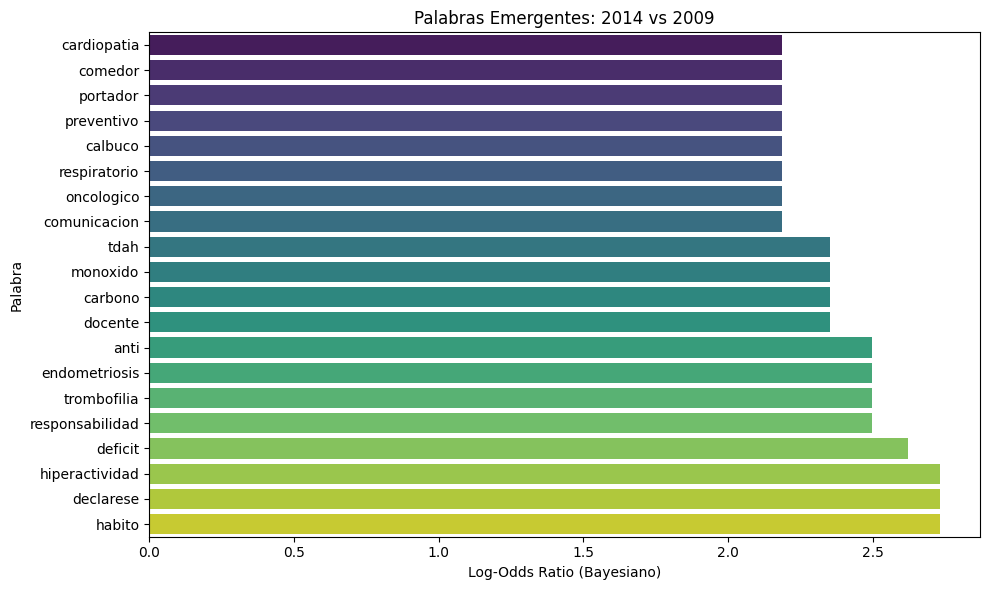

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3871079248.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


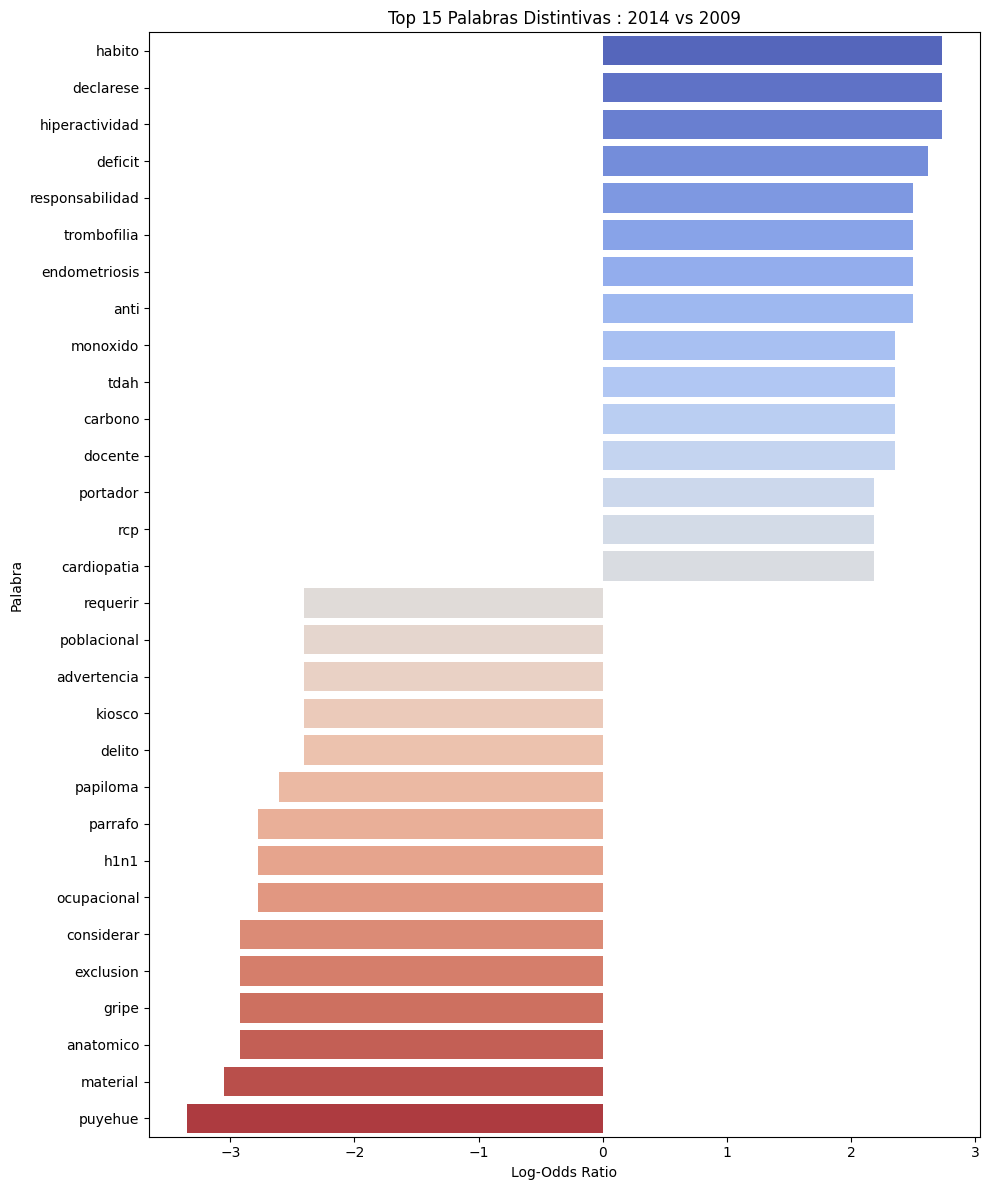


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes : 811

--- Palabras emergentes en 2019 comparado con 2014 ---


,Frecuencia_2014,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
covid,0.0,104.0,5.305231,True
crear,0.0,53.0,4.630691,True
pandemia,0.0,47.0,4.511148,True
coronavirus,0.0,24.0,3.846831,True
plasma,0.0,15.0,3.388114,True
recuperado,0.0,11.0,3.089229,True
comercial,0.0,10.0,2.998159,True
suicidio,0.0,9.0,2.897977,True
prorrogar,0.0,8.0,2.786654,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\2372005113.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


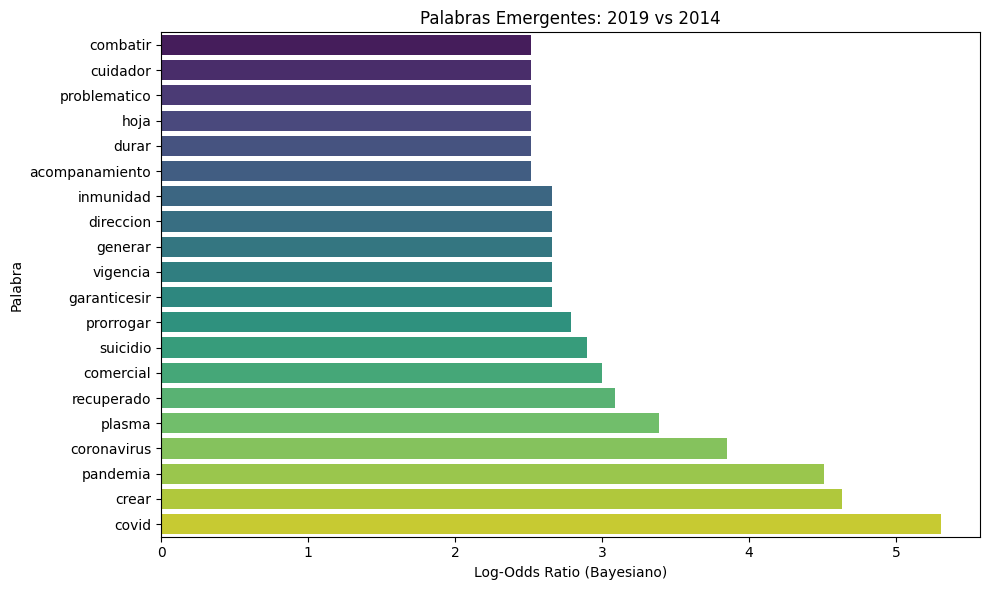

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3871079248.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


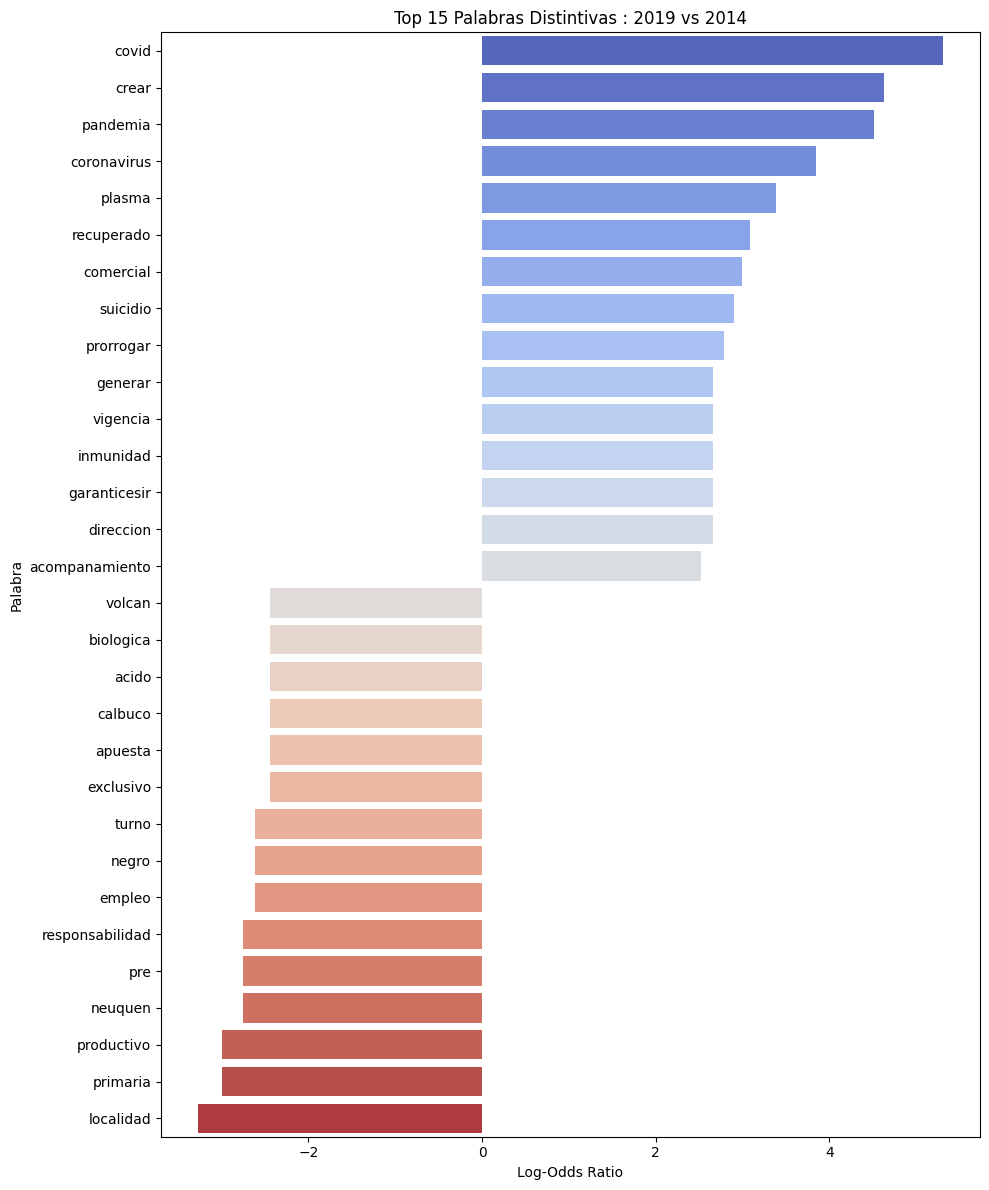


--- Comparación entre 2009 y 2019 ---
Cantidad de palabras emergentes : 489

--- Palabras emergentes en 2019 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
covid,0.0,104.0,5.093082,True
crear,0.0,53.0,4.418542,True
endometriosis,0.0,32.0,3.918034,True
coronavirus,0.0,24.0,3.634681,True
acompanamiento,0.0,19.0,3.405932,True
plasma,0.0,15.0,3.175965,True
declarese,0.0,15.0,3.175965,True
abordaje,0.0,13.0,3.037618,True
incorporese,0.0,12.0,2.960559,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\2372005113.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


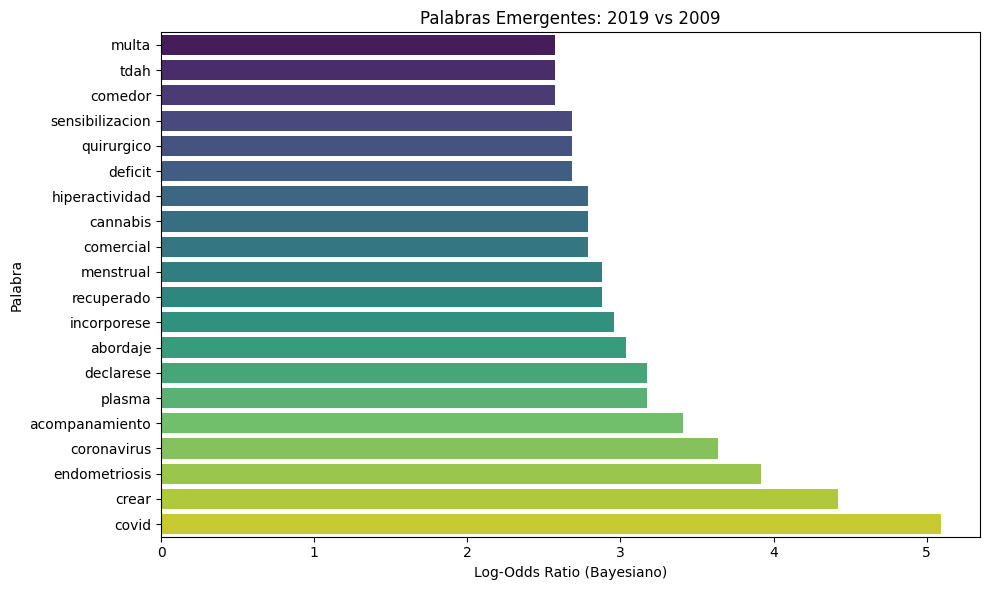

C:\Users\Usuario\AppData\Local\Temp\ipykernel_5844\3871079248.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")


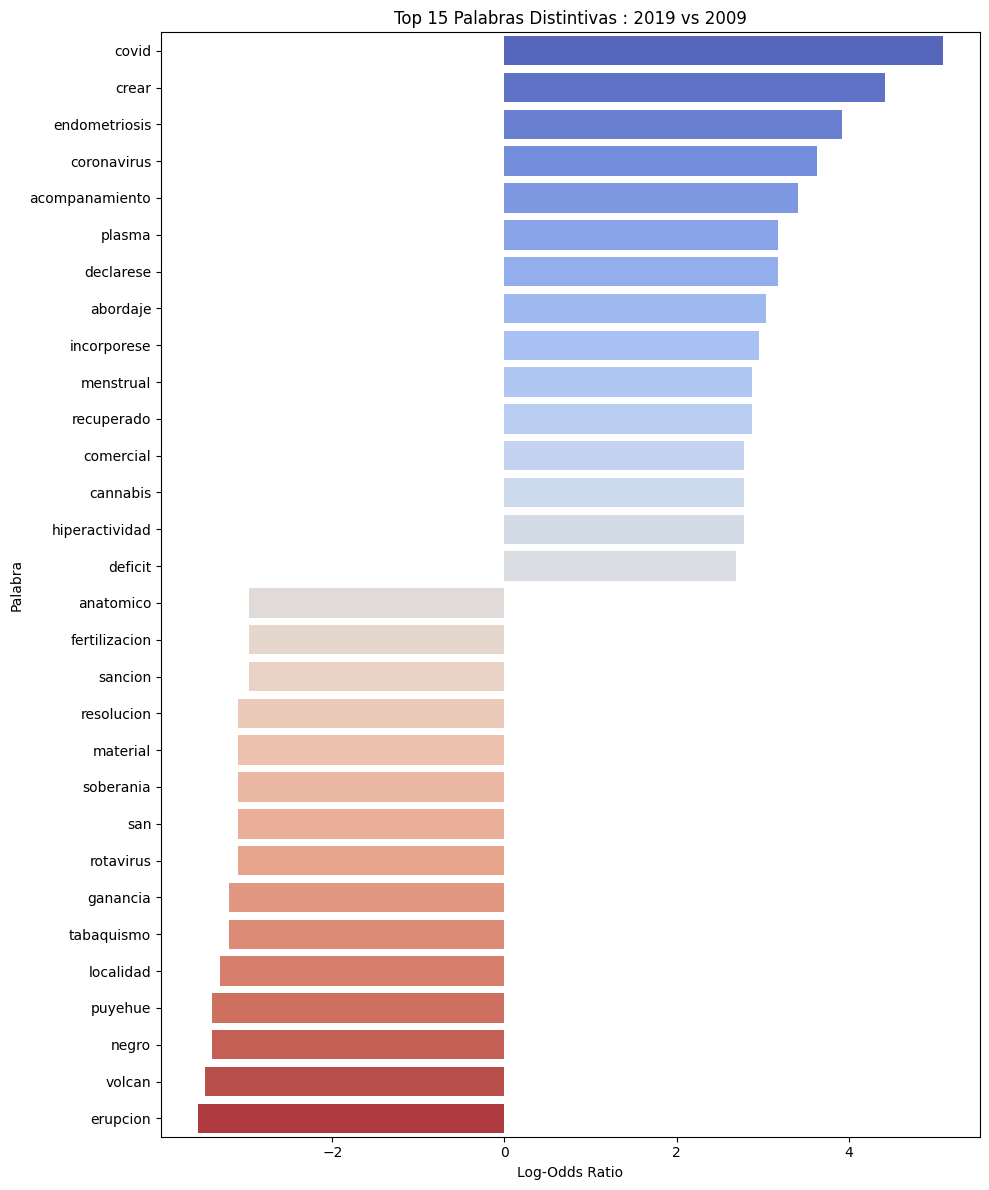

In [48]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]

for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    periodo_emergente = p2
    periodo_referencia = p1

    resultados_emergentes = identificar_palabras_emergentes_lor(
        freqs_df.copy(), periodo_referencia, periodo_emergente, prior=0.5, umbral_lor=1
    )

    resultados_emergentes.to_csv(RESULTADOS_DIR+'/archivos_out/lor_'+p1+'_'+p2+'.csv')
    print("Cantidad de palabras emergentes :",len(resultados_emergentes[resultados_emergentes['es_emergente']==True]))

    print(f"\n--- Palabras emergentes en {periodo_emergente} comparado con {periodo_referencia} ---")
    display(resultados_emergentes.head(10))
    visualizar_palabras_emergentes_lor(resultados_emergentes, title=f"Palabras Emergentes: {periodo_emergente} vs {periodo_referencia}")
    visualizar_top_odds_ratios(resultados_emergentes, 'log_odds_ratio', n=15, title=f"Top 15 Palabras Distintivas : {periodo_emergente} vs {periodo_referencia}")


LOR > 0: Indica que la palabra tiene una mayor probabilidad de aparecer en el grupo 1 (generalmente el periodo de tiempo más reciente o el corpus de interés) en comparación con el grupo 2 (el periodo de referencia). Cuanto mayor sea el valor positivo, más fuerte es la evidencia de que la palabra está emergiendo o aumentando su uso en el grupo 1.

LOR < 0: Indica que la palabra tiene una menor probabilidad de aparecer en el grupo 1 en comparación con el grupo 2. Un valor negativo grande sugiere que la palabra está disminuyendo su uso o era más común en el grupo de referencia.


LOR ≈ 0: Indica que la probabilidad de la palabra es similar en ambos grupos. Estas palabras probablemente no son emergentes ni en declive significativo.

Se consider un prior pequeño y constante como 0.5. Esta es una práctica común. Habría que analizar otros.

* El análisis del log-odds ratio entre los períodos 2009–2013 y 2014–2018 revela la emergencia de nuevos términos asociados principalmente a la salud mental infantil (tdah, hiperactividad, déficit) y la salud reproductiva femenina (endometriosis, trombofilia) .
* La comparación entre los períodos 2014–2018 y 2019–2023 muestra palabras que influyen en un cambio semántico abrupto, vinculado principalmente a la pandemia de COVID-19. Palabras como “covid”, “pandemia” y “coronavirus” emergen con log-odds elevados, reflejando la centralidad de la crisis sanitaria en la agenda legislativa.
* La comparación entre los extremos del período (2009–2013 vs. 2019–2023) visibiliza la influencia de COVID-19 en cuanto a nuevos términos como “covid” y “coronavirus” y a una transformación en el lenguaje legislativo “crear”, “incorpórese”, “acompañamiento” e “abordaje". La existencia de palabra de “endometriosis” como palabra emergente podría relacionarse con salud reproductiva.

##### TF-IDF por período 

In [49]:
docs_por_periodo = pd.Series(PER5anios_df['Título normalizado'].values, index =PER5anios_df['Periodo_5anios'])
docs_por_periodo

Periodo_5anios
2009                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [50]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


# Aplicamos TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(docs_por_periodo)

# Creamos un DataFrame con los resultados
tfidf_df = pd.DataFrame(tfidf_matrix.T.toarray(), 
                        index=vectorizer.get_feature_names_out(), 
                        columns=docs_por_periodo.index)

# Mostrar las top palabras distintivas por período
for periodo in tfidf_df.columns:
    print(f"\n Palabras más distintivas en {periodo}")
    display(tfidf_df[periodo].sort_values(ascending=False).head(10))


 Palabras más distintivas en 2009


nacional       0.401821
creacion       0.303298
salud          0.256934
programa       0.216365
social         0.212502
regimen        0.204774
ley            0.197047
obligatorio    0.162274
medico         0.150683
declarar       0.150683
Name: 2009, dtype: float64


 Palabras más distintivas en 2014


nacional       0.416032
creacion       0.341519
regimen        0.315128
programa       0.256139
salud          0.240615
medico         0.187835
obligatorio    0.150579
social         0.142817
persona        0.139712
tratamiento    0.138160
Name: 2014, dtype: float64


 Palabras más distintivas en 2019


nacional       0.475165
creacion       0.331296
programa       0.278499
salud          0.257381
covid          0.232418
regimen        0.232303
persona        0.143869
medico         0.143869
obligatorio    0.139910
integral       0.135950
Name: 2019, dtype: float64

Se aplicó la métrica TF-IDF sobre los textos agrupados por períodos de 5 años, considerando cada período como un “documento agregado”. Esta estrategia permitió identificar términos con alta relevancia local, palabras distintivas que caracterizan el discurso legislativo sobre salud en cada período analizado.

In [51]:

def mostrar_ejemplos_contextuales_titulos(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de títulos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de títulos) y 'periodo'.
        palabra (str): La palabra para buscar en los títulos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    titulos_con_palabra = df_periodo[df_periodo['Título normalizado'].str.lower().str.contains(palabra.lower(), na=False)]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de títulos conteniendo '{palabra}' en el periodo {periodo}:")
        display(titulos_con_palabra[['Título','Título normalizado']].head(n))
    
    else:
        print(f"No se encontraron títulos conteniendo '{palabra}' en el periodo {periodo}.")


### Para Análisis Cualitativo y semático 

In [52]:
basetexto_df.columns

Index(['Proyecto.ID', 'Título', 'Título procesado', 'Título normalizado',
       'Cant_token', 'Cant_token_normalizado',
       'Proyecto_girado_a_comisiones_SALUD', 'Proyecto_SALUD', 'Resultado',
       'Max_Orden', 'Tiene_antecedente_por_titulo_proy', 'Periodo', 'Año',
       'Tokens', 'Periodo_5anios'],
      dtype='object')

In [53]:
# Ejemplo de cómo usar la función para ver el contexto
palabra_ejemplo = 'nacional'
for periodo in [2009,2014,2019]:
    mostrar_ejemplos_contextuales_titulos(basetexto_df.copy(), palabra_ejemplo, periodo, n=3)




Ejemplos de títulos conteniendo 'nacional' en el periodo 2009:


,Título,Título normalizado
25671,CREACION EN EL AMBITO DEL MINISTERIO DE SALUD DE LA NACION EL REGISTRO UNIVERSAL SANITARIO NACIONAL.,creacion ambito ministerio salud nacion registro universal sanitario nacional
25674,"INCORPORACION AL CALENDARIO NACIONAL DE VACUNACION, LAS DOSIS DE VACUNAS CONTRA LA VARICELA, SIENDO ESTAS DE CARACTER OBLIGATORIO.",incorporacion calendario nacional vacunacion dosis vacuna varicela caracter obligatorio
25708,"ATENCION MEDICA, INVESTIGACION CLINICA Y EPIDEMIOLOGICA, CAPACITACION PROFESIONAL EN LA DETECCION TEMPRANA, DIAGNOSTICO DIFUSION Y TRATAMIENTO DE LAS ALERGIAS ALIMENTARIAS. DECLARACION DE INTERES NACIONAL.",atencion medica investigacion clinico epidemiologico capacitacion profesional deteccion diagnostico difusion tratamiento alergia alimentario declaracion inter nacional



Ejemplos de títulos conteniendo 'nacional' en el periodo 2014:


,Título,Título normalizado
12613,"EMERGENCIA SANITARIA NACIONAL - DECRETO 486/02 -. MODIFICACIONES, SOBRE FINANCIAMIENTO Y REGIMEN DE COMPRAS.",emergencia sanitario nacional decreto modificacion financiamiento regimen compra
12817,PROGRAMA NACIONAL DE ATENCION MEDICA SEXUAL AMBULATORIA. CREACION.,programa nacional atencion medica sexual ambulatorio creacion
12823,DECLARESE AL MANI ARGENTINO COMO ALIMENTO NACIONAL.,declarese mani argentino alimento nacional



Ejemplos de títulos conteniendo 'nacional' en el periodo 2019:


,Título,Título normalizado
2061,INCLUYASE EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE. MODIFICACION DE LA LEY 27491.,incluyar calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue
2067,INCLUIR EN EL CALENDARIO NACIONAL DE VACUNACION CON CARACTER OBLIGATORIO Y GRATUITO LA VACUNA CONTRA EL VIRUS DEL DENGUE.,incluir calendario nacional vacunacion caracter obligatorio gratuito vacuna virus dengue
2100,CONTROL DE ENFERMEDADES PREVENIBLES POR VACUNACION - LEY 27491-. MODIFICACIONES SOBRE LA INCORPORACION DE LA VACUNA CONTRA EL DENGUE EN EL CALENDARIO NACIONAL.,control enfermedad prevenibl vacunacion incorporacion vacuna dengue calendario nacional


INICIATIVA LEGISLATIVA
* Iniciativas total : 35179
* Vocabulario : 12865
* Top 4 palabras con mayores frecuencias:
nacional (10119), creacion (6033), regimen(5828), ley(5262). No se las eliminaron aún.

INICIATIVA LEGISLATIVA DE SALUD
* Iniciativas total : 2848 (8% del total)
* Vocabulario: 3221 (25% del total)
* Top 5 palabras con mayores frecuencias:  
nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 
* N-gramas más frecuentes top 6 (mas diferencia con el resto). Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1: 
	* programa nacional  (2-grama)     208 veces
	* medico obligatorio (2-grama)     187 veces
	* programa medico obligatorio (3-grama)         153 veces
	* programa medico         153 veces
	* obligatorio pmo         150 veces
	* medico obligatorio pmo  150 veces


CORPUS POR PERIODO DE 5 AÑOS
* Desde 2009 a 2024, 16 años : promedio de cantidad palabras por título normalizado es 9. La media de 9 es una estimación del promedio anual de tokens para el periodo de 16 años. 
La mayoría de los promedios anuales de tokens se encuentran relativamente cerca de la media de 9. 

Análisis general (Tres Periodos Combinados)
	
	
* Existe un alta variabilidad de frecuencia de palabra en período de 5 años (rango = 360 frecuencia).
* La mayoría de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se  concentran alrededor de frecuencia=2. 
* El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4.
* Se considera que una palabra en período de 5 años con frecuencia superior 8 es una palabra de frecuencia extrema o especial. 
* Hay 316 palabras únicas por período que superan las 8 veces en alguno de los tres períodos. 
* Total de palabras con frecuencia extrema en alguno de los tres periodo = 622 

Análisis por Periodo:  Por período de 5 años
Los vocabularios o las cantidades de palabras únicas por período están dispersos.
La media 1854 no es tan representativa para los tres periodos a procesar, pero aún así no indica la existencia de vocabularios relativamente pequeños (menor diversidad léxica?)para entrenar embeddings de palabras robustos y para analizar la detección de cambios semánticos de manera confiable con las técnicas estándar.

--- Periodo: 2009 ---
Tamaño del vocabulario único: 1717
Frecuencia total de palabras: 7874
Frecuencia media de las palabras (BCa): 4.59 (IC 95%: 4.12, 5.23)
['nacional' 'creacion' 'salud' 'programa' 'social' 'regimen' 'ley'
 'obligatorio' 'medico' 'declarar']
 
 
--- Periodo: 2014 ---
Tamaño del vocabulario único: 1969
Frecuencia total de palabras: 9735
Frecuencia media de las palabras (BCa): 4.94 (IC 95%: 4.44, 5.66)
['nacional' 'creacion' 'regimen' 'programa' 'salud' 'medico' 'obligatorio'
 'social' 'persona' 'tratamiento']



--- Periodo: 2019 ---
Tamaño del vocabulario único: 1876
Frecuencia total de palabras: 10207
Frecuencia media de las palabras (BCa): 5.44 (IC 95%: 4.84, 6.35)
['nacional' 'creacion' 'programa' 'salud' 'regimen' 'medico' 'persona'
 'obligatorio' 'covid' 'integral']



* Frecuencia media con intervalos de confianza: el promedio de ocurrencias de una palabra en el periodo, es en general, un frecuencia de ocurrencia igual a 5.
* El intervalo de confianza te proporciona un rango dentro del cual es probable que se encuentre la verdadera frecuencia media de las palabras en la población (todos los posibles títulos de ese periodo). Los intervalos de confianza para el promedio de ocurrencias de una palabra en el periodo para diferentes periodos en general no se superponen, se observa para el periodo 2019 una frecuencia media de 6.




En general, 29% del vocabulario total de pares de periodos a comparar es compartido, es decir  que solo el 29% de las palabras únicas que aparecen en la unión de los vocabularios de ambos periodos están presentes en ambos periodos. El 71% restante del vocabulario total aparece solo en uno de los dos periodos comparados.

En vocabularios pequeños, un solapamiento del 29% puede tener un impacto en el análisis de cambio semántico:

* Menos palabras para comparar
* Mayor impacto de palabras nuevas y desaparecidas
* La falta de datos compartidos puede llevar a representaciones inestables o poco confiables para las palabras en embedding.

Palabras emergente 

* Se observan palabras de alta frecuencia con Z-Scores extremos, tal que están presentes en los tres períodos. Por ejemplo **"nacional" y "programa", "creacion" son palabras con alta frecuencia y Z-scores extremos entre los períodos comparados 2009 y 2019. Podriamos interpretar que sus usos se ha incrementado en el período (2019-2024] aún más en relación con el resto del vocabulario del periodo (2009-2014]. Al estar presentes en los tres periodos, las palabras pueden indicar continuidad de temática centrales sobre salud por ejemplo asociado al ambito o planificación.
* log-odds ratio al corregir el ruido de palabras que aparecen muy poco, identifica palabras emergentes que no están necesariamente en los tres períodos.
Palabras como “covid”, “pandemia” y “coronavirus” emergen con log-odds elevados, reflejando la centralidad de la crisis sanitaria en la agenda legislativa.










	
	












	
	